## packages

In [1]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [2]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [3]:
tw1 = data_preprocess('Blockhouse Data 1.csv')
tw2 = data_preprocess('Blockhouse Data 2.csv')
tw3 = data_preprocess('Blockhouse Data 3.csv')
tw4 = data_preprocess('Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [4]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [5]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [6]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [7]:
filtered_rawdata.shape

(50741, 11)

In [8]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN'] * 10

filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [9]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [10]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [11]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


## daily_vol, adv, beta

In [12]:
filtered_rawdata.MATURITY_RANGE.value_counts()

,count
MATURITY_RANGE,
Note 1.5 - 3.5 Year,12244
Note 0 - 1.5 Year,9955
Note >10 Year,8946
Note 5.5 - 10 Year,8760
Note 3.5 - 5.5 Year,7661
TIPS 0 - 5 year,1620
TIPS > 10 year,782
TIPS 5 - 10 year,773


In [13]:
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 1.5 - 3.5 Year']
group1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:50:42,D38,1323.10,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,97.101562,1,13231.0,2,0.011719
2023-10-02 07:46:44,D7,2020.00,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,99.351562,1,20200.0,2,0.007812
2023-10-02 08:22:38,D74,202.00,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,96.199219,-1,-2020.0,1,0.019531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:50:21,D28,8080.00,100.968918,91282CHM6,Note 1.5 - 3.5 Year,2026-07-15,2023-12-29,4.500,BUY,100.984375,100.953125,1,80800.0,2,0.015625
2023-12-29 13:50:21,D38,8080.00,101.523606,91282CJC6,Note 1.5 - 3.5 Year,2026-10-15,2023-12-29,4.625,BUY,101.539062,101.515625,1,80800.0,2,0.011719
2023-12-29 13:50:21,D74,14140.00,101.414231,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-12-29,4.625,BUY,101.437500,101.414062,1,141400.0,2,0.011719


In [14]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

In [15]:
group1.Daily_Volatility

,Daily_Volatility
TIMESTAMP,
2023-10-02 06:47:43,3.636997
2023-10-02 06:47:43,3.636997
2023-10-02 06:50:42,3.636997
2023-10-02 07:46:44,3.636997
2023-10-02 08:22:38,3.636997
...,...
2023-12-29 13:50:21,3.605377
2023-12-29 13:50:21,3.605377
2023-12-29 13:50:21,3.605377


In [16]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum() * 10
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [17]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    2029226.35
2023-10-03    2300066.94
2023-10-04    1177301.45
2023-10-05    1162227.20
2023-10-06    2131342.40
2023-10-07          0.00
2023-10-08          0.00
2023-10-09          0.00
2023-10-10    4103338.11
2023-10-11    1181639.40
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [18]:
group1.ADV

,ADV
TIMESTAMP,
2023-10-02 06:47:43,380.218540
2023-10-02 06:47:43,380.218540
2023-10-02 06:50:42,380.218540
2023-10-02 07:46:44,380.218540
2023-10-02 08:22:38,380.218540
...,...
2023-12-29 13:50:21,170.450478
2023-12-29 13:50:21,170.450478
2023-12-29 13:50:21,170.450478


In [19]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 2029226.35
DEC 1177301.45


In [20]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


## qt

In [21]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 60-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [22]:
group1['SIGN'].unique()

array([ 1, -1])

In [23]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME          qt
TIMESTAMP                                     
2023-10-02 06:47:43        39390.0     55600.5
2023-10-02 06:47:43         2979.5     55600.5
2023-10-02 06:50:42        13231.0     55600.5
2023-10-02 07:46:44        20200.0     20200.0
2023-10-02 08:22:38        -2020.0     12776.5
...                            ...         ...
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21       141400.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5

[12244 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00       55600.50
2023-10-02 07:00:00       20200.00
2023-10-02 08:00:00       12776.50
2023-10-02 09:00:00       45106.60
2023-10-02 10:00:00      385991.70
                          ...     
2023-12-29 09:00:00      172260.55
2023-12-29 10:00:00     4229462.87
2023-12-29 11:00:00     -788880.70
2023-12-29 12:00:00     7086503.40
202

In [24]:
(group1.qt == 0).value_counts()

,count
qt,
False,12244


In [25]:
# Function to calculate I_t and v_t using the given equations from book
def calculate_impact_and_liquidity(data, beta, delta_t, lambda_value):
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        # Calculate v_t+delta_t using the exponential moving sum of volume
        v_values[i] = v_values[i-1] + (-beta * v_values[i-1] * delta_t + abs(qt))

        # Calculate I_t+delta_t using the impact equation
        if adv_value != 0:
            I_values[i] = I_values[i-1] + (-beta * I_values[i-1] * delta_t +
                                           lambda_value * sigma_value * (qt / np.sqrt(adv_value*v_values[i])))

    # Append the calculated values to the DataFrame for further analysis
    data['I_t'] = I_values
    data['v_t'] = v_values

    # Include PRICE in the returned DataFrame to calculate Delta_P in the next function
    return data

### func to find lambda

In [26]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [27]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472     0.000020     0.002903
      12.0     3.465736     0.000012     0.002805
      18.0     2.310491     0.000008     0.002196
      24.0     1.732868     0.000006     0.002152
      30.0     1.386294     0.000006     0.002449
      48.0     0.866434     0.000002     0.000931
      60.0     0.693147     0.000003     0.003058
      90.0     0.462098     0.000002     0.001335
     120.0     0.346574     0.000002     0.003898
--------------------------------------------------------------------------------


set $\lambda = 0.000002$

In [28]:
def ow(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data


In [29]:
df_it = ow(group1, h_minutes=120, delta_t=1/24)

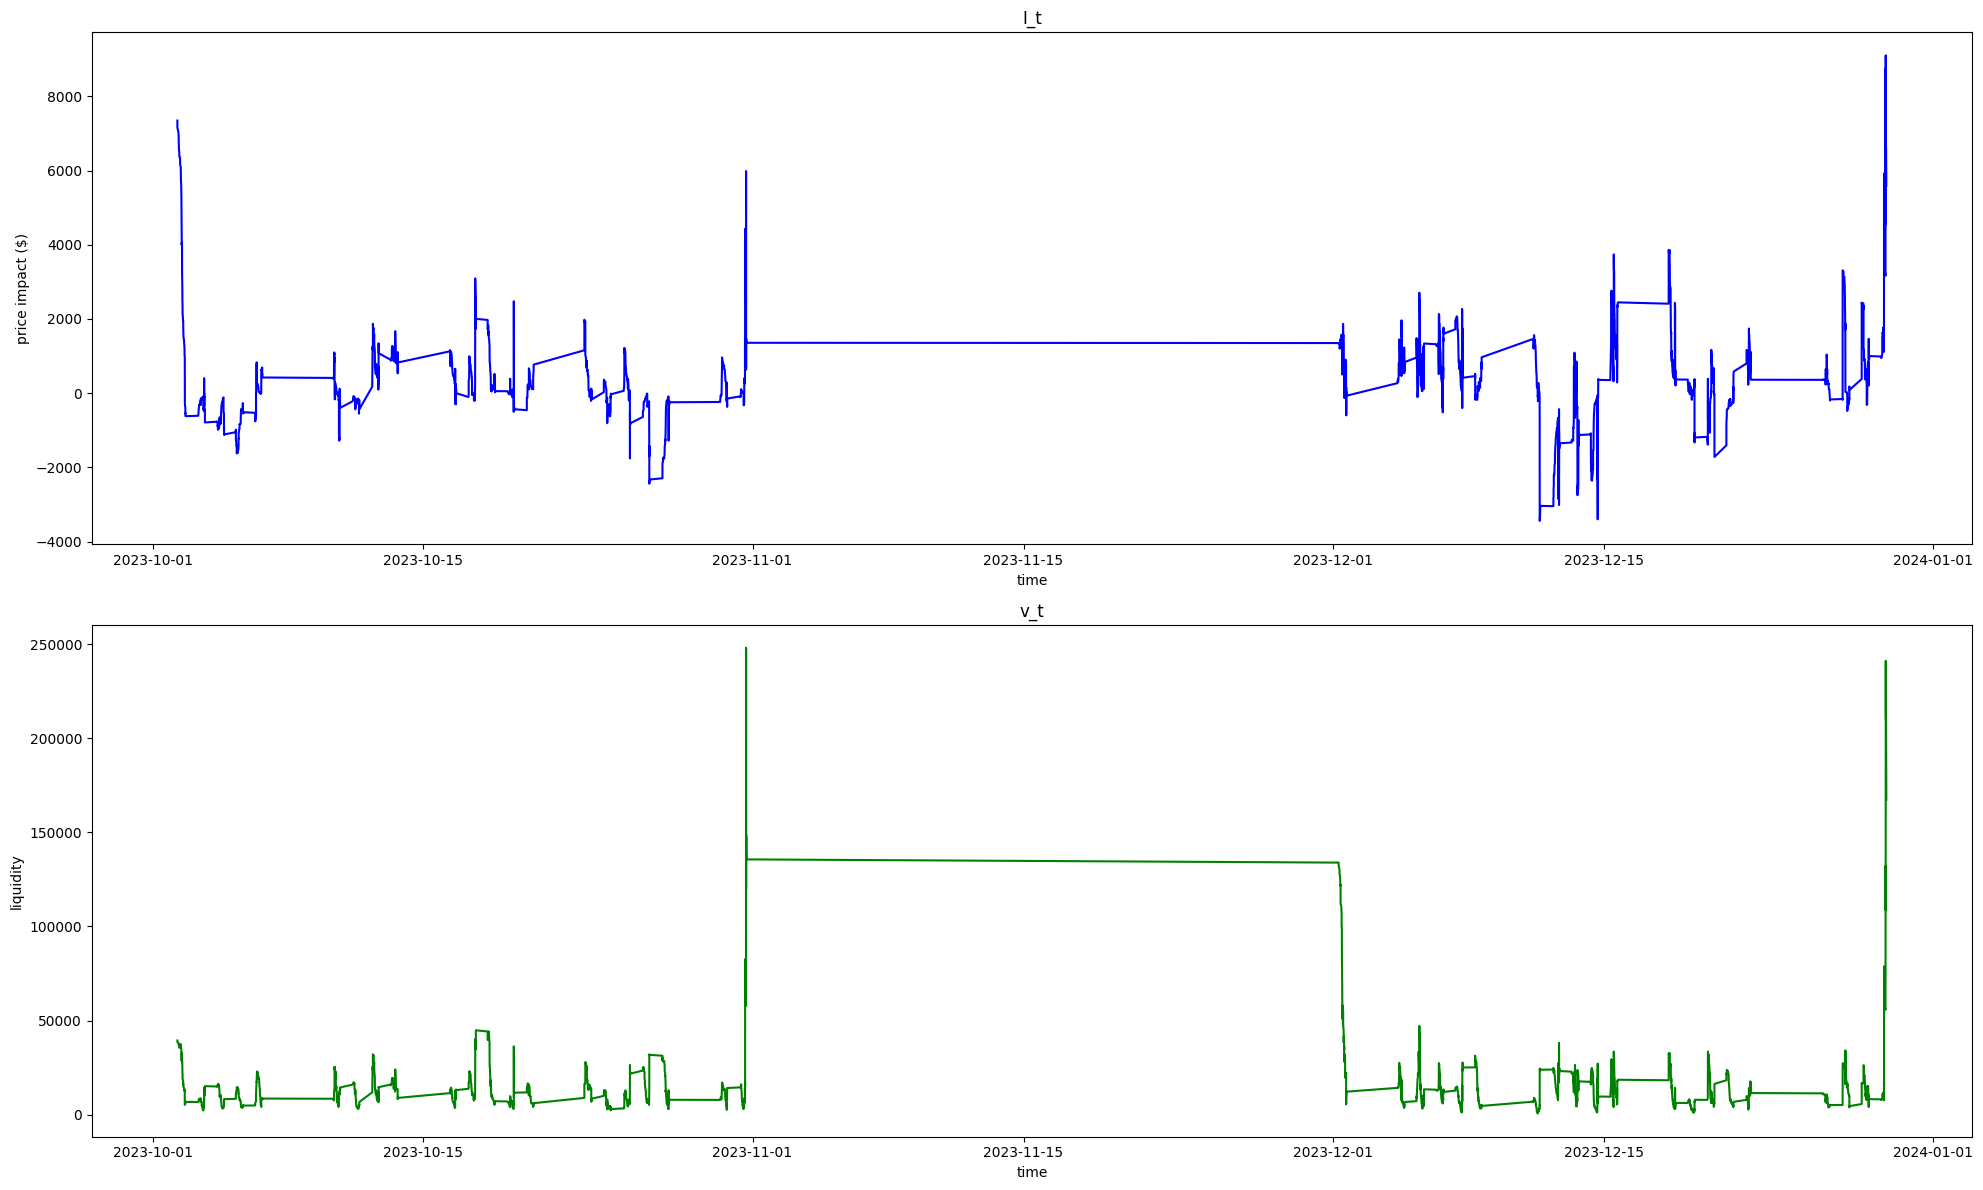

In [30]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact ($)')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity')
plt.title('v_t')

plt.tight_layout()
plt.show()


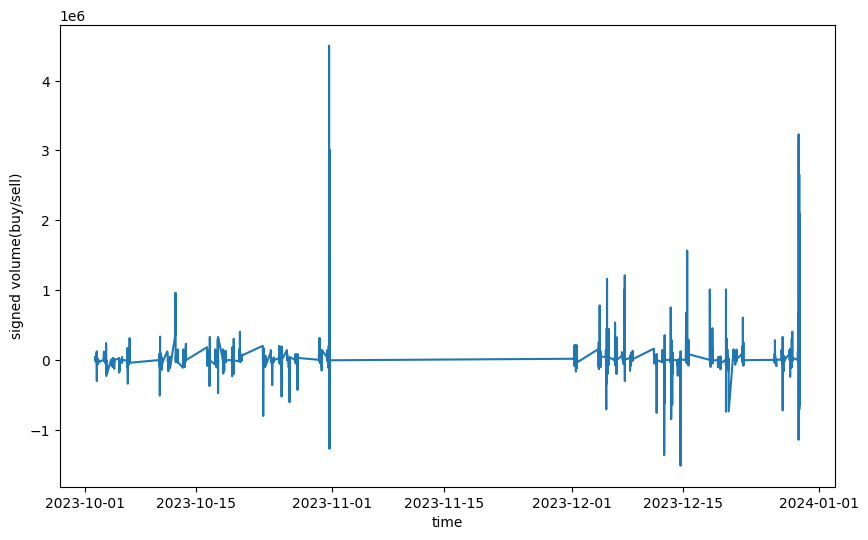

In [31]:
plt.figure(figsize=(10,6))
plt.plot(df_it.SIGNED_VOLUME)
plt.xlabel('time')
plt.ylabel('signed volume(buy/sell)')
plt.show()

In [32]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


In [33]:
# Calculate Slippage
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)

In [34]:
group1_oct_dec = group1[(group1.index.month == 10) | (group1.index.month == 12)]

In [35]:
def assign_time_session(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 9 or (hour == 9 and timestamp.minute < 30):
        return "Pre-market"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Mid-day"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Post-market"

group1_oct_dec['Time_Session'] = group1_oct_dec.index.map(assign_time_session)

In [36]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 10 * 100
# Filter data separately for October and December
group1_oct = group1[group1.index.month == 10]
group1_dec = group1[group1.index.month == 12]

group1_oct['Time_Session'] = group1_oct.index.map(assign_time_session)
group1_dec['Time_Session'] = group1_dec.index.map(assign_time_session)

group1_oct['Weighted_Slippage'] = group1_oct['Slippage_bps'] * group1_oct['ACCEPTEDVOL'] * 10

# October volume-weighted average slippage
volume_weighted_slippage_oct = group1_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage_bps_Oct')


group1_dec['Weighted_Slippage'] = group1_dec['Slippage_bps'] * group1_dec['ACCEPTEDVOL'] * 10

#  December volume-weighted average slippage
volume_weighted_slippage_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['SIGNED_VOLUME'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage_bps_Dec')


notional_oct = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_oct')

notional_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_dec')


print("Volume-Weighted Slippage for October:")
print(volume_weighted_slippage_oct)

print('Notional Value for October:')
print(notional_oct)

print("\nVolume-Weighted Slippage for December:")
print(volume_weighted_slippage_dec)

print('Notional Value for December:')
print(notional_dec)

Volume-Weighted Slippage for October:
Time_Session
Afternoon      0.001749
Mid-day       -0.001811
Morning       -0.000822
Post-market    0.000006
Pre-market     0.002811
Name: Volume_Weighted_Slippage_bps_Oct, dtype: float64
Notional Value for October:
Time_Session
Afternoon      1.122855e+09
Mid-day        3.383065e+09
Morning        2.565649e+09
Post-market    2.099799e+09
Pre-market     1.380651e+09
Name: Notional_Value_oct, dtype: float64

Volume-Weighted Slippage for December:
Time_Session
Afternoon      0.000190
Mid-day        0.000497
Morning        0.000037
Post-market   -0.000148
Pre-market    -0.000035
Name: Volume_Weighted_Slippage_bps_Dec, dtype: float64
Notional Value for December:
Time_Session
Afternoon      1.122855e+09
Mid-day        3.383065e+09
Morning        2.565649e+09
Post-market    2.099799e+09
Pre-market     1.380651e+09
Name: Notional_Value_dec, dtype: float64


In [37]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t'],
      dtype='object')

In [38]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t'] #* df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['AcceptedVol']
)

# Display the results for October and December
print(session_metrics_monthly[['Signed_Volume_Weighted_Price_Impact', 'Total_Signed_Volume']])

                         Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon                              310.242763   
           Mid-day                                178.240187   
           Morning                                245.639820   
           Post-market                            222.222601   
           Pre-market                             620.661794   
2023-12    Afternoon                               52.051605   
           Mid-day                                851.452745   
           Morning                                601.571792   
           Post-market                             17.221708   
           Pre-market                             644.720070   

                         Total_Signed_Volume  
Year_Month Time_Session                       
2023-10    Afternoon             10684055.73  
           Mid-day                  62109.95  
           Morning                -537408.8

# market session

In [39]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage'] = group1.apply(calculate_slippage, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 10 * 100  # Calculate notional value

# Define Year_Month and Time_Session
group1['Year_Month'] = group1.index.to_period('M')  # Convert to Year-Month for grouping
group1['Time_Session'] = group1.index.map(assign_time_session)  # Assign time sessions based on the time of day

# Calculate Volume Weighted Slippage
group1['Weighted_Slippage'] = group1['Slippage'] * group1['ACCEPTEDVOL'] * 10

# Calculate volume-weighted average slippage, notional value, accepted volume, and dealer count by time session
volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Time_Session'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Time_Session'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Time_Session'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()


df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly as per your code
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = session_metrics_monthly['Price_Impact']

session_metrics_monthly = session_metrics_monthly.reset_index()

session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Time_Session'], inplace=True)

final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Price_Impact', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Time_Session                                        
2023-10    Afternoon       3.150259e+09          10684055.73   
           Mid-day         4.347166e+08             62109.95   
           Morning         7.943517e+08           -537408.88   
           Post-market     3.283967e+09           2595829.28   
           Pre-market      1.160907e+09           6124144.09   
2023-12    Afternoon       1.122855e+09          -2178874.01   
           Mid-day         3.383065e+09          19356836.85   
           Morning         2.565649e+09           9861615.76   
           Post-market     2.099799e+09           -665306.19   
           Pre-market      1.380651e+09           6715727.35   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon               3150259.387    310.242763   
           Mid-day                  434716.625    178.240187   
           Morning                  794351.668    245.639820   
           Post-market             3283966.722    222.222601   
           Pre-market              1160907.029    620.661794   
2023-12    Afternoon               1122855.279     52.051605   
           Mid-day                 3383065.195    851.452745   
           Morning                 2565648.864    601.571792   
           Post-market             2099799.191     17.221708   
           Pre-market              1380651.315    644.720070   

                         Volume_Weighted_Slippage  Dealer_Count  
Year_Month Time_Session                                          
2023-10    Afternoon                     0.001749            21  
           Mid-day                      -0.001811            21  
           Morning                      -0.000822            20  
           Post-market                   0.000006            18  
           Pre-market                    0.002811            17  
2023-12    Afternoon                     0.001900            20  
           Mid-day                       0.004966            19  
           Morning                       0.000373            20  
           Post-market                  -0.001476            21  
           Pre-market                   -0.000348            20

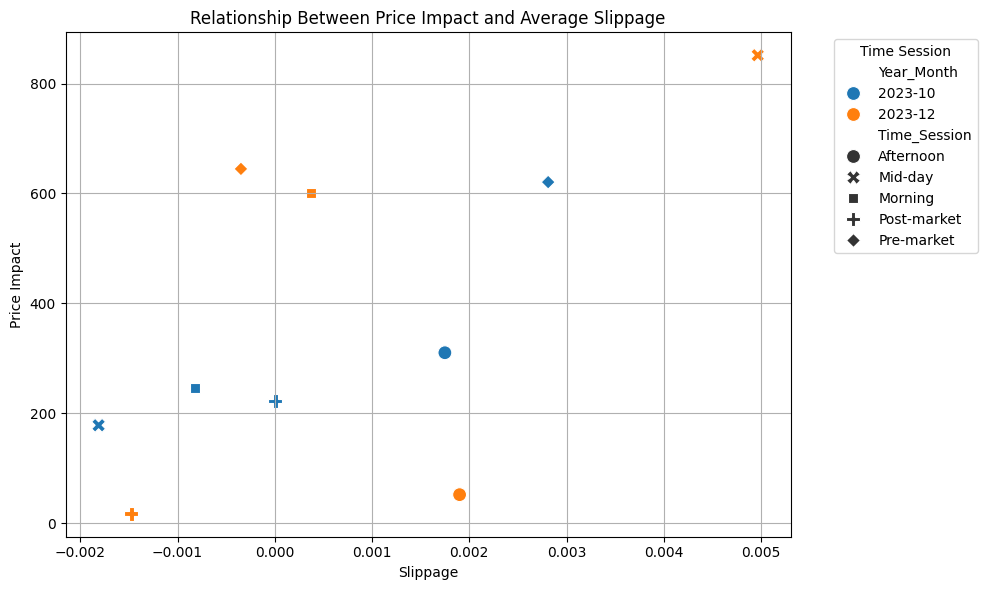

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes
plt.figure(figsize=(10, 6))

# Scatter plot of Total Signed Volume vs. Price Impact
sns.scatterplot(
    data=final_table.reset_index(),
    x="Volume_Weighted_Slippage",
    y="Price_Impact",
    hue="Year_Month",  # Color by month for differentiation
    style="Time_Session",  # Different marker style for each time session
    s=100  # Set marker size
)

# Adding labels and title
plt.xlabel("Slippage")
plt.ylabel("Price Impact")
plt.title("Relationship Between Price Impact and Average Slippage")
plt.legend(title="Time Session", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

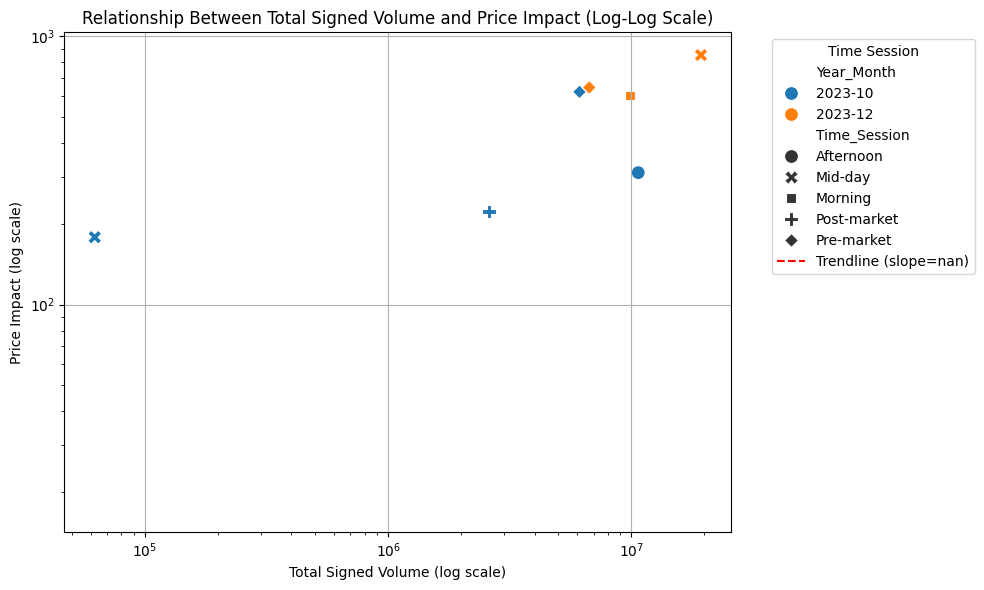

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Step 1: Drop rows with NaN values in `Total_Signed_Volume` or `Price_Impact`
plot_data = final_table.reset_index()[['Total_Signed_Volume', 'Price_Impact', 'Year_Month', 'Time_Session']].dropna()

# Step 2: Set up the figure and axes with logarithmic x and y scales
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x="Total_Signed_Volume",
    y="Price_Impact",
    hue="Year_Month",
    style="Time_Session",
    s=100
)
plt.xscale('log')
plt.yscale('log')  # Logarithmic y-axis for better visualization

# Step 3: Calculate and plot the trendline manually
# Apply log transformation to both x and y for linear regression on log-log scale
log_x = np.log(plot_data['Total_Signed_Volume'])
log_y = np.log(plot_data['Price_Impact'])
slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

# Generate points for the trendline
x_vals = np.linspace(plot_data['Total_Signed_Volume'].min(), plot_data['Total_Signed_Volume'].max(), 100)
y_vals = np.exp(intercept) * x_vals ** slope  # Transform back from log scale

# Plot the trendline
plt.plot(x_vals, y_vals, color="red", linestyle="--", label=f"Trendline (slope={slope:.2f})")

# Adding labels and title
plt.xlabel("Total Signed Volume (log scale)")
plt.ylabel("Price Impact (log scale)")
plt.title("Relationship Between Total Signed Volume and Price Impact (Log-Log Scale)")
plt.legend(title="Time Session", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [41]:
final_table.columns

Index(['Total_Signed_Volume', 'Price_Impact',
       'Signed_Volume_Weighted_Price_Impact', 'Volume_Weighted_Slippage',
       'Trade_Notional', 'Total_Accepted_Volume', 'Dealer_Count'],
      dtype='object')

# first 3 weeks and last week

In [51]:
import pandas as pd

# Step 1: Define Year_Month, Week_Group, and Time_Session in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage'] * group1['ACCEPTEDVOL'] * 10

# Step 2: Calculate metrics for each Year_Month and Week_Group
# Calculate Volume Weighted Slippage
volume_weighted_slippage = group1.groupby(['Year_Month', 'Week_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage')

# Calculate Notional Value
notional_value = group1.groupby(['Year_Month', 'Week_Group'])['Notional_Value'].sum().rename('Notional_Value')

# Calculate Dealer Count (unique dealers per Year_Month and Week_Group)
dealer_count = group1.groupby(['Year_Month', 'Week_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into a single DataFrame
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Dealer_Count': dealer_count
}).reset_index()

# Step 3: Process `df_it` for Signed Volume Weighted Price Impact with week grouping
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)
df_oct_dec['Week_Group'] = df_oct_dec.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

# Group by Year_Month and Week_Group for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Week_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

# Calculate Average Price Impact
session_metrics_monthly['Average_Price_Impact'] = session_metrics_monthly['Total_Signed_Volume_Weighted_Impact']

# Reset index for merging compatibility
session_metrics_monthly = session_metrics_monthly.reset_index()

# Step 4: Merge session metrics with combined_data on Year_Month and Week_Group
final_table = session_metrics_monthly.merge(combined_data, on=['Year_Month', 'Week_Group'], how='left')

final_table.set_index(['Year_Month', 'Week_Group'], inplace=True)

final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Average_Price_Impact', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Week_Group                                           
2023-10    First_3_Weeks    3.777889e+09           8769431.05   
           Last_Week        5.046313e+09          10159299.12   
2023-12    First_3_Weeks    6.085540e+09           8037826.44   
           Last_Week        4.466480e+09          25052173.32   

                          Average_Price_Impact  Volume_Weighted_Slippage  \
Year_Month Week_Group                                                      
2023-10    First_3_Weeks            333.211028                 -0.001538   
           Last_Week                 98.830614                  0.002609   
2023-12    First_3_Weeks            216.218532                 -0.000853   
           Last_Week               1243.062447                  0.004815   

                          Dealer_Count  
Year_Month Week_Group                   
2023-10    First_3_Weeks            21  
           Last_Week                22  
2023-12    First_3_Weeks            24  
           Last_Week                20

In [52]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 10 * 100  # Calculate notional value

group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Year_Month'] = group1.index.to_period('M')  # Year-Month for grouping

group1['Time_Session'] = group1.index.map(assign_time_session)

group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL'] * 10

volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session', 'Week_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Time_Session', 'Week_Group'])['Notional_Value'].sum().rename('Notional_Value')

combined_data = pd.DataFrame({'Volume_Weighted_Slippage': volume_weighted_slippage, 'Notional_Value': notional_value}).reset_index()

df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['SIGNED_VOLUME'] * df_oct_dec['I_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')
df_oct_dec['Week_Group'] = df_oct_dec.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')


session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'Week_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'sum')
)

session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] / session_metrics_monthly['Total_Signed_Volume'].abs()
)

# Reset index
session_metrics_monthly = session_metrics_monthly.reset_index()

session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session', 'Week_Group'], how='left'
)

final_table.set_index(['Year_Month', 'Time_Session', 'Week_Group'], inplace=True)

final_table

Total_Signed_Volume  \
Year_Month Time_Session Week_Group                           
2023-10    Afternoon    First_3_Weeks            674530.52   
                        Last_Week              10009525.21   
           Mid-day      First_3_Weeks            212226.25   
                        Last_Week               -150116.30   
           Morning      First_3_Weeks           -707083.83   
                        Last_Week                169674.95   
           Post-market  First_3_Weeks           4008904.12   
                        Last_Week              -1413074.84   
           Pre-market   First_3_Weeks           4580853.99   
                        Last_Week               1543290.10   
2023-12    Afternoon    First_3_Weeks          -2742787.31   
                        Last_Week                563913.30   
           Mid-day      First_3_Weeks           2176433.85   
                        Last_Week              17180403.00   
           Morning      First_3_Weeks           6452899.09   
                        Last_Week               3408716.67   
           Post-market  First_3_Weeks          -1193435.19   
                        Last_Week                528129.00   
           Pre-market   First_3_Weeks           3344716.00   
                        Last_Week               3371011.35   

                                       Total_Signed_Volume_Weighted_Impact  \
Year_Month Time_Session Week_Group                                           
2023-10    Afternoon    First_3_Weeks                         2.021023e+09   
                        Last_Week                             6.737488e+10   
           Mid-day      First_3_Weeks                         9.294397e+06   
                        Last_Week                             1.009902e+08   
           Morning      First_3_Weeks                         3.490970e+09   
                        Last_Week                             9.090911e+08   
           Post-market  First_3_Weeks                         1.124243e+10   
                        Last_Week                             9.652693e+09   
           Pre-market   First_3_Weeks                         5.184580e+09   
                        Last_Week                             3.796789e+08   
2023-12    Afternoon    First_3_Weeks                         1.951181e+10   
                        Last_Week                             2.852683e+08   
           Mid-day      First_3_Weeks                         3.253211e+09   
                        Last_Week                             1.207257e+11   
           Morning      First_3_Weeks                         1.606460e+10   
                        Last_Week                             1.840197e+10   
           Post-market  First_3_Weeks                         1.516549e+10   
                        Last_Week                             7.330328e+08   
           Pre-market   First_3_Weeks                         1.159040e+10   
                        Last_Week                             5.906261e+09   

                                       Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session Week_Group                                           
2023-10    Afternoon    First_3_Weeks                          2996.191444   
                        Last_Week                              6731.076620   
           Mid-day      First_3_Weeks                            43.794755   
                        Last_Week                               672.746528   
           Morning      First_3_Weeks                          4937.137915   
                        Last_Week                              5357.839009   
           Post-market  First_3_Weeks                          2804.365027   
                        Last_Week                              6830.985131   
           Pre-market   First_3_Weeks                          1131.793346   
                        Last_Week                               246.019145   
2023-12    Afternoon 

# Dealers

In [71]:
import pandas as pd

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage'] * group1['ACCEPTEDVOL'] * 10

# Separate data for October and December
oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# Ensure `I_t` is available for `Price_Impact` calculation by joining with `df_it`
# Reset indices to prepare for the join operation based on the actual index values
oct_data = oct_data.reset_index().set_index(oct_data.index)
dec_data = dec_data.reset_index().set_index(dec_data.index)

# Join `I_t` values from `df_it` based on the original index
oct_data = oct_data.join(df_it[['I_t']], how='left', rsuffix='_impact')
dec_data = dec_data.join(df_it[['I_t']], how='left', rsuffix='_impact')

# Step 2: Calculate metrics, including Price Impact for each dealer
def calculate_metrics(df):
    # Assume that `I_t` represents price impact, use directly for average calculation
    df['Price_Impact'] = df['I_t']

    metrics = df.groupby('DEALER').agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Notional_Value=('Notional_Value', 'sum'),
        Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / (df['ACCEPTEDVOL'].abs().sum() * 10)),
        Average_Price_Impact=('Price_Impact', 'mean')
    ).reset_index()
    return metrics

# Calculate metrics for October and December
oct_dealer_metrics = calculate_metrics(oct_data)
dec_dealer_metrics = calculate_metrics(dec_data)

# Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# For October
top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# For December
top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# Add a Month column for clarity in the combined table
top_5_dealers_oct['Month'] = 'October'
bottom_5_dealers_oct['Month'] = 'October'
top_5_dealers_dec['Month'] = 'December'
bottom_5_dealers_dec['Month'] = 'December'

# Concatenate all tables into a single DataFrame
combined_top_bottom = pd.concat([
    top_5_dealers_oct, bottom_5_dealers_oct,
    top_5_dealers_dec, bottom_5_dealers_dec
])

# Add a Rank column to indicate top or bottom dealers
combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# Step 5: Display the final combined table
print("Combined Top and Bottom 5 Dealers in October and December:")
print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Average_Price_Impact']])

Combined Top and Bottom 5 Dealers in October and December:
       Month      Rank DEALER  Total_Signed_Volume  Total_Accepted_Volume  \
11   October     Top 5    D50           9806213.22            4960845.078   
2    October     Top 5    D28           9794282.09            4188988.231   
18   October     Top 5     D7           9147509.40            3376017.920   
22   October     Top 5    D74          -5342319.25            2553339.085   
12   October     Top 5    D54          -1127101.42            2100388.122   
7    October  Bottom 5    D37              1878.60                187.860   
4    October  Bottom 5    D30             -2242.20                224.220   
23   October  Bottom 5    D79             -5050.00                505.000   
15   October  Bottom 5    D61            -98980.00              10302.000   
5    October  Bottom 5    D31            110090.00              11009.000   
4   December     Top 5    D28            558716.85            3490152.465   
15  December     

In [72]:
combined_top_bottom

,DEALER,Total_Signed_Volume,Total_Accepted_Volume,Notional_Value,Weighted_Volume_Slippage,Average_Price_Impact,Month,Rank
11,D50,9806213.22,4960845.078,4.960845e+09,2.129225e-04,248.642226,October,Top 5
2,D28,9794282.09,4188988.231,4.188988e+09,1.477564e-04,399.290943,October,Top 5
18,D7,9147509.40,3376017.920,3.376018e+09,1.356874e-06,444.617815,October,Top 5
22,D74,-5342319.25,2553339.085,2.553339e+09,1.606494e-05,237.729177,October,Top 5
12,D54,-1127101.42,2100388.122,2.100388e+09,2.484332e-04,145.676663,October,Top 5
7,D37,1878.60,187.860,1.878600e+05,-4.024829e-08,324.705262,October,Bottom 5
4,D30,-2242.20,224.220,2.242200e+05,-8.578258e-08,-181.514052,October,Bottom 5
23,D79,-5050.00,505.000,5.050000e+05,2.810058e-09,-1541.535659,October,Bottom 5
15,D61,-98980.00,10302.000,1.030200e+07,1.052448e-05,1264.514291,October,Bottom 5
5,D31,110090.00,11009.000,1.100900e+07,7.734437e-07,2596.545570,October,Bottom 5


In [73]:
# Set Month and Rank as the index for better organization
combined_top_bottom.set_index(['Month', 'Rank'], inplace=True)

# Display the final table with Month and Rank as indices
combined_top_bottom = combined_top_bottom[['DEALER', 'Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact', 'Weighted_Volume_Slippage']]
combined_top_bottom

DEALER  Notional_Value  Total_Signed_Volume  \
Month    Rank                                                   
October  Top 5       D50    4.960845e+09           9806213.22   
         Top 5       D28    4.188988e+09           9794282.09   
         Top 5        D7    3.376018e+09           9147509.40   
         Top 5       D74    2.553339e+09          -5342319.25   
         Top 5       D54    2.100388e+09          -1127101.42   
         Bottom 5    D37    1.878600e+05              1878.60   
         Bottom 5    D30    2.242200e+05             -2242.20   
         Bottom 5    D79    5.050000e+05             -5050.00   
         Bottom 5    D61    1.030200e+07            -98980.00   
         Bottom 5    D31    1.100900e+07            110090.00   
December Top 5       D28    3.490152e+09            558716.85   
         Top 5       D54    3.188175e+09           1102320.06   
         Top 5       D50    3.050810e+09          14834993.12   
         Top 5       D63    2.972278e+09           4892399.60   
         Top 5       D74    2.044730e+09            634308.28   
         Bottom 5     D8    2.525000e+04               252.50   
         Bottom 5    D24    2.020000e+06             20200.00   
         Bottom 5    D31    3.030000e+06            -30300.00   
         Bottom 5     D1    3.535000e+06             35350.00   
         Bottom 5    D72    8.289070e+06            -58388.10   

                   Total_Accepted_Volume  Average_Price_Impact  \
Month    Rank                                                    
October  Top 5               4960845.078            248.642226   
         Top 5               4188988.231            399.290943   
         Top 5               3376017.920            444.617815   
         Top 5               2553339.085            237.729177   
         Top 5               2100388.122            145.676663   
         Bottom 5                187.860            324.705262   
         Bottom 5                224.220           -181.514052   
         Bottom 5                505.000          -1541.535659   
         Bottom 5              10302.000           1264.514291   
         Bottom 5              11009.000           2596.545570   
December Top 5               3490152.465            286.351528   
         Top 5               3188175.494            298.917567   
         Top 5               3050810.242            301.583018   
         Top 5               2972278.500            358.250938   
         Top 5               2044729.648            311.080276   
         Bottom 5                 25.250            356.472346   
         Bottom 5               2020.000            542.453811   
         Bottom 5               3030.000             -7.110171   
         Bottom 5               3535.000            377.087684   
         Bottom 5               8289.070             24.007829   

                   Weighted_Volume_Slippage  
Month    Rank                                
October  Top 5                 2.129225e-04  
         Top 5                 1.477564e-04  
         Top 5                 1.356874e-06  
         Top 5                 1.606494e-05  
         Top 5                 2.484332e-04  
         Bottom 5             -4.024829e-08  
         Bottom 5             -8.578258e-08  
         Bottom 5              2.810058e-09  
         Bottom 5              1.052448e-05  
         Bottom 5              7.734437e-07  
December Top 5                -2.696335e-04  
         Top 5                 5.649606e-04  
         Top 5                 1.698375e-04  
         Top 5                -8.504322e-04  
         Top 5                -4.775116e-05  
         Bottom 5              1.548276e-10  
         Bottom 5              0.000000e+00  
         Bottom 5              4.505760e-07  
         Bottom 5              2.736739e-07  
         Bottom 5             -2.209524e-06